In [1]:
# Cell 1: Imports
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Cell 2: Load Raw CSV

RAW_DATA_PATH = '../data/bengaluru_traffic_incidents.csv'
df_raw = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print(f'Shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}')
print('\nEvent type distribution:')
print(df_raw['event_type'].value_counts())

Shape: (8173, 46)
Columns (46): ['id', 'event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude', 'address', 'end_address', 'event_cause', 'requires_road_closure', 'start_datetime', 'end_datetime', 'status', 'authenticated', 'modified_datetime', 'map_file', 'direction', 'description', 'veh_type', 'veh_no', 'corridor', 'priority', 'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date', 'route_path', 'client_id', 'created_by_id', 'last_modified_by_id', 'assigned_to_police_id', 'citizen_accident_id', 'comment', 'police_station', 'meta_data', 'kgid', 'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id', 'closed_datetime', 'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone', 'junction']

Event type distribution:
event_type
unplanned    7706
planned       467
Name: count, dtype: int64


In [3]:
# Cell 3: Data Audit for Agent 3 columns

AGENT3_COLS = [
    'start_datetime', 'closed_datetime', 'resolved_datetime',
    'zone', 'police_station', 'priority'
]

print('=== Null Analysis (Agent 3 Columns) ===')
for col in AGENT3_COLS:
    if col in df_raw.columns:
        n = df_raw[col].isnull().sum()
        pct = n / len(df_raw) * 100
        print(f'  {col:<25} -> {n} nulls ({pct:.1f}%)')
    else:
        print(f'  {col:<25} -> MISSING COLUMN')

print('\n=== Priority Value Counts ===')
print(df_raw['priority'].value_counts(dropna=False))
print('\n=== Zone Value Counts (top 10) ===')
print(df_raw['zone'].value_counts(dropna=False).head(10))

=== Null Analysis (Agent 3 Columns) ===
  start_datetime            -> 0 nulls (0.0%)
  closed_datetime           -> 5032 nulls (61.6%)
  resolved_datetime         -> 8099 nulls (99.1%)
  zone                      -> 4729 nulls (57.9%)
  police_station            -> 0 nulls (0.0%)
  priority                  -> 2 nulls (0.0%)

=== Priority Value Counts ===
priority
High    5030
Low     3141
NaN        2
Name: count, dtype: int64

=== Zone Value Counts (top 10) ===
zone
NaN               4729
Central Zone 2     623
West Zone 1        433
North Zone 2       413
West Zone 2        358
South Zone 2       354
North Zone 1       318
Central Zone 1     269
East Zone 1        253
South Zone 1       233
Name: count, dtype: int64


In [4]:
# Cell 4: prepare_data() 

def _get_time_bucket(hour: int) -> str:
    """Source: anomaly_detector.py:51-66"""
    if 6 <= hour < 10:
        return 'morning_peak'
    elif 10 <= hour < 16:
        return 'afternoon'
    elif 16 <= hour < 21:
        return 'evening_peak'
    else:
        return 'night'

def _get_day_type(day_of_week: int) -> str:
    """Source: anomaly_detector.py:68-72"""
    return 'weekend' if day_of_week in [5, 6] else 'weekday'

def _compute_resolution_minutes(df):
    """Source: anomaly_detector.py:28-49
    closed_datetime is primary; resolved_datetime is fallback."""
    start = pd.to_datetime(df['start_datetime'], errors='coerce')
    res_min = pd.Series(np.nan, index=df.index)
    if 'closed_datetime' in df.columns:
        closed = pd.to_datetime(df['closed_datetime'], errors='coerce')
        res_min = (closed - start).dt.total_seconds() / 60.0
    if 'resolved_datetime' in df.columns:
        resolved = pd.to_datetime(df['resolved_datetime'], errors='coerce')
        res_min_fallback = (resolved - start).dt.total_seconds() / 60.0
        res_min = res_min.fillna(res_min_fallback)
    return res_min

def prepare_data(df):
    """Source: anomaly_detector.py:74-103"""
    df = df.copy()
    df['start_datetime_parsed'] = pd.to_datetime(df['start_datetime'], errors='coerce')
    # Null-zone fallback: group null zones by police_station
    zone_series = df['zone'] if 'zone' in df.columns else pd.Series(np.nan, index=df.index)
    ps_series   = df['police_station'] if 'police_station' in df.columns else pd.Series(np.nan, index=df.index)
    df['zone_or_station'] = zone_series.fillna(ps_series).fillna('Unknown')
    df['hour_of_day'] = df['start_datetime_parsed'].dt.hour
    df['day_of_week'] = df['start_datetime_parsed'].dt.dayofweek
    df['time_bucket'] = df['hour_of_day'].apply(
        lambda h: _get_time_bucket(int(h)) if pd.notnull(h) else 'night'
    )
    df['day_type'] = df['day_of_week'].apply(
        lambda d: _get_day_type(int(d)) if pd.notnull(d) else 'weekday'
    )
    df['resolution_minutes'] = _compute_resolution_minutes(df)
    return df

df_clean = prepare_data(df_raw)

print(f'After prepare_data() -- shape: {df_clean.shape}')
print(f'Unique zone_or_station values: {df_clean["zone_or_station"].nunique()}')
print(f'Records with zone (not null): {df_raw["zone"].notnull().sum()} ({df_raw["zone"].notnull().sum()/len(df_raw)*100:.1f}%)')
print(f'Records using police_station fallback: {df_raw["zone"].isnull().sum()} ({df_raw["zone"].isnull().sum()/len(df_raw)*100:.1f}%)')
print('\ntime_bucket distribution:')
print(df_clean['time_bucket'].value_counts())
print('\nday_type distribution:')
print(df_clean['day_type'].value_counts())
valid_mask = (df_clean['resolution_minutes'] > 0) & (df_clean['resolution_minutes'] <= 1440)
print(f'\nresolution_minutes valid (0 < x <= 1440): {valid_mask.sum()}')

After prepare_data() -- shape: (8173, 53)
Unique zone_or_station values: 64
Records with zone (not null): 3444 (42.1%)
Records using police_station fallback: 4729 (57.9%)

time_bucket distribution:
time_bucket
night           4762
morning_peak    1627
evening_peak    1530
afternoon        254
Name: count, dtype: int64

day_type distribution:
day_type
weekday    6020
weekend    2153
Name: count, dtype: int64

resolution_minutes valid (0 < x <= 1440): 2523


In [5]:
# Cell 5: Compute overall_mean_duration (global fallback)

valid_durations = df_clean['resolution_minutes'].dropna()
valid_durations = valid_durations[(valid_durations > 0) & (valid_durations <= 1440)]

overall_mean_duration = float(valid_durations.mean()) if len(valid_durations) > 0 else 60.0

print(f'Valid duration records (0 < x <= 1440): {len(valid_durations):,}')
print(f'overall_mean_duration (global fallback): {overall_mean_duration:.2f} min')
print(f'Median                                : {valid_durations.median():.2f} min')
print(f'P25                                   : {valid_durations.quantile(0.25):.2f} min')
print(f'P75                                   : {valid_durations.quantile(0.75):.2f} min')
print(f'P99                                   : {valid_durations.quantile(0.99):.2f} min')
print(f'Max (pre-filter)                      : {df_clean["resolution_minutes"].max():.0f} min')

Valid duration records (0 < x <= 1440): 2,523
overall_mean_duration (global fallback): 98.51 min
Median                                : 46.08 min
P25                                   : 22.23 min
P75                                   : 85.26 min
P99                                   : 1322.66 min
Max (pre-filter)                      : 201789 min


In [6]:
# Cell 6: Build baseline statistics 
# --- Step 1: mean_incident_count (lines 122-133) ---
df_clean['date'] = df_clean['start_datetime_parsed'].dt.date

daily_counts = df_clean.groupby(
    ['date', 'zone_or_station', 'day_type', 'time_bucket']
).size().reset_index(name='daily_count')

mean_daily_counts = daily_counts.groupby(
    ['zone_or_station', 'day_type', 'time_bucket']
)['daily_count'].mean().reset_index(name='mean_incident_count')

print(f'Step 1 -- mean_incident_count: {len(mean_daily_counts):,} groups')
print(mean_daily_counts['mean_incident_count'].describe().round(3))

# --- Step 2: high_priority_ratio (lines 135-141) ---
df_clean['is_high_priority'] = df_clean['priority'].apply(
    lambda p: 1 if str(p).strip().lower() == 'high' else 0
)
priority_stats = df_clean.groupby(
    ['zone_or_station', 'day_type', 'time_bucket']
)['is_high_priority'].mean().reset_index(name='high_priority_ratio')

print(f'\nStep 2 -- high_priority_ratio: {len(priority_stats):,} groups')
print(priority_stats['high_priority_ratio'].describe().round(3))

# --- Step 3: mean_duration_minutes (lines 143-150) ---
df_valid_dur = df_clean[
    (df_clean['resolution_minutes'] > 0) &
    (df_clean['resolution_minutes'] <= 1440)
]
duration_stats = df_valid_dur.groupby(
    ['zone_or_station', 'day_type', 'time_bucket']
)['resolution_minutes'].mean().reset_index(name='mean_duration_minutes')

print(f'\nStep 3 -- mean_duration_minutes: {len(duration_stats):,} groups')
print(f'  (using {len(df_valid_dur):,} records with valid 0-1440 min durations)')
print(duration_stats['mean_duration_minutes'].describe().round(2))

Step 1 -- mean_incident_count: 450 groups
count   450.000
mean      1.478
std       0.709
min       1.000
25%       1.000
50%       1.300
75%       1.625
max       6.667
Name: mean_incident_count, dtype: float64

Step 2 -- high_priority_ratio: 450 groups
count   450.000
mean      0.560
std       0.359
min       0.000
25%       0.250
50%       0.638
75%       0.870
max       1.000
Name: high_priority_ratio, dtype: float64

Step 3 -- mean_duration_minutes: 353 groups
  (using 2,523 records with valid 0-1440 min durations)
count    353.000
mean     112.670
std      151.520
min        1.610
25%       43.550
50%       64.360
75%      104.510
max     1228.070
Name: mean_duration_minutes, dtype: float64


In [7]:
# Cell 7: Merge into baseline DataFrame and fill NaN defaults

baseline = pd.merge(
    mean_daily_counts, priority_stats,
    on=['zone_or_station', 'day_type', 'time_bucket'], how='outer'
)
baseline = pd.merge(
    baseline, duration_stats,
    on=['zone_or_station', 'day_type', 'time_bucket'], how='outer'
)

baseline['mean_incident_count']   = baseline['mean_incident_count'].fillna(0.0)
baseline['high_priority_ratio']   = baseline['high_priority_ratio'].fillna(0.0)
baseline['mean_duration_minutes'] = baseline['mean_duration_minutes'].fillna(overall_mean_duration)

print(f'Baseline shape: {baseline.shape}')
print(f'Unique zones/stations: {baseline["zone_or_station"].nunique()}')
print('\nFeature summary:')
print(baseline[['mean_incident_count','high_priority_ratio','mean_duration_minutes']].describe().round(3))
print('\nNull check after fill:')
print(baseline[['mean_incident_count','high_priority_ratio','mean_duration_minutes']].isnull().sum())
baseline.head()

Baseline shape: (450, 6)
Unique zones/stations: 64

Feature summary:
       mean_incident_count  high_priority_ratio  mean_duration_minutes
count              450.000              450.000                450.000
mean                 1.478                0.560                109.619
std                  0.709                0.359                134.286
min                  1.000                0.000                  1.605
25%                  1.000                0.250                 47.110
50%                  1.300                0.638                 81.103
75%                  1.625                0.870                 98.507
max                  6.667                1.000               1228.069

Null check after fill:
mean_incident_count      0
high_priority_ratio      0
mean_duration_minutes    0
dtype: int64


,zone_or_station,day_type,time_bucket,mean_incident_count,high_priority_ratio,mean_duration_minutes
0,Adugodi,weekday,evening_peak,1.111,0.700,153.672
1,Adugodi,weekday,morning_peak,1.600,0.500,85.562
2,Adugodi,weekday,night,1.304,0.567,58.377
3,Adugodi,weekend,evening_peak,1.000,0.667,98.507
4,Adugodi,weekend,morning_peak,1.667,0.200,62.196


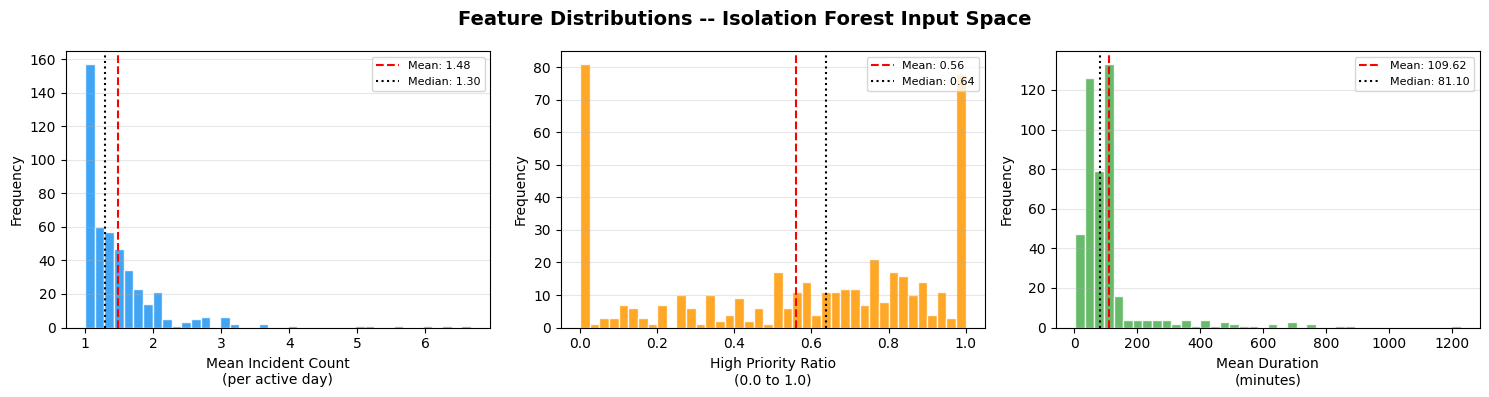

Feature distribution plot saved.


In [8]:
# Cell 8: Visualise the 3D feature space before training
# Dense-core + sparse-tail shape is exactly what Isolation Forest exploits.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions -- Isolation Forest Input Space', fontsize=14, fontweight='bold')

FEATURES = ['mean_incident_count', 'high_priority_ratio', 'mean_duration_minutes']
COLORS   = ['#2196F3', '#FF9800', '#4CAF50']
LABELS   = ['Mean Incident Count\n(per active day)', 'High Priority Ratio\n(0.0 to 1.0)', 'Mean Duration\n(minutes)']

for ax, feat, color, label in zip(axes, FEATURES, COLORS, LABELS):
    ax.hist(baseline[feat], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(baseline[feat].mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean: {baseline[feat].mean():.2f}')
    ax.axvline(baseline[feat].median(), color='black', linestyle=':',  linewidth=1.5, label=f'Median: {baseline[feat].median():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../models/anomaly_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature distribution plot saved.')

In [9]:
# Cell 9: Train Isolation Forest 

X = baseline[['mean_incident_count', 'high_priority_ratio', 'mean_duration_minutes']].values

print(f'Training Isolation Forest on X: shape={X.shape}')
print(f'  Feature 1 mean_incident_count : min={X[:,0].min():.2f}, max={X[:,0].max():.2f}')
print(f'  Feature 2 high_priority_ratio : min={X[:,1].min():.2f}, max={X[:,1].max():.2f}')
print(f'  Feature 3 mean_duration_min   : min={X[:,2].min():.2f}, max={X[:,2].max():.2f}')

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
model.fit(X)

print(f'\nIsolation Forest fitted on {len(X)} baseline rows.')
print(f'  n_estimators : {model.n_estimators}')
print(f'  contamination: {model.contamination}')
print(f'  offset_      : {model.offset_:.4f}  (decision threshold)')

Training Isolation Forest on X: shape=(450, 3)
  Feature 1 mean_incident_count : min=1.00, max=6.67
  Feature 2 high_priority_ratio : min=0.00, max=1.00
  Feature 3 mean_duration_min   : min=1.61, max=1228.07

Isolation Forest fitted on 450 baseline rows.
  n_estimators : 100
  contamination: 0.05
  offset_      : -0.5859  (decision threshold)


In [10]:
# Cell 10: Score the baseline and map to alert levels

scores = model.decision_function(X)
baseline['anomaly_score'] = scores

def score_to_level(s: float) -> str:
    if s > 0.0:
        return 'Normal'
    elif s >= -0.1:
        return 'Watch'
    else:
        return 'Critical'

baseline['alert_level'] = baseline['anomaly_score'].apply(score_to_level)

print('=== Anomaly Score Statistics ===')
print(baseline['anomaly_score'].describe().round(4))

print('\n=== Alert Level Distribution ===')
level_counts = baseline['alert_level'].value_counts()
total = len(baseline)
for level, count in level_counts.items():
    print(f'  {level:<10}: {count:4d}  ({count/total*100:.1f}%)')

anomaly_frac = (baseline['alert_level'] != 'Normal').sum() / total * 100
print(f'\nTarget contamination: 5.0%  ->  Actual anomaly fraction: {anomaly_frac:.1f}%')

=== Anomaly Score Statistics ===
count   450.000
mean      0.133
std       0.063
min      -0.148
25%       0.120
50%       0.151
75%       0.175
max       0.198
Name: anomaly_score, dtype: float64

=== Alert Level Distribution ===
  Normal    :  427  (94.9%)
  Watch     :   16  (3.6%)
  Critical  :    7  (1.6%)

Target contamination: 5.0%  ->  Actual anomaly fraction: 5.1%


In [11]:
# Cell 11: Inspect top anomalies (Critical and Watch zones)

critical = baseline[baseline['alert_level'] == 'Critical'].sort_values('anomaly_score')
watch    = baseline[baseline['alert_level'] == 'Watch'].sort_values('anomaly_score')

DISPLAY_COLS = ['zone_or_station', 'day_type', 'time_bucket',
                'mean_incident_count', 'high_priority_ratio',
                'mean_duration_minutes', 'anomaly_score']

print('=== Top 20 Critical Baseline Rows (most anomalous) ===')
print(critical[DISPLAY_COLS].head(20).to_string(index=False))
print('\n=== Top 10 Watch Baseline Rows ===')
print(watch[DISPLAY_COLS].head(10).to_string(index=False))

=== Top 20 Critical Baseline Rows (most anomalous) ===
zone_or_station day_type  time_bucket  mean_incident_count  high_priority_ratio  mean_duration_minutes  anomaly_score
HAL Old Airport  weekend morning_peak                6.667                0.950                 35.916         -0.148
   Basavanagudi  weekday    afternoon                3.000                0.000                744.424         -0.130
   South Zone 2  weekend        night                6.375                0.784                 49.035         -0.122
     Jayanagara  weekend evening_peak                6.000                0.000                 98.507         -0.121
   Basavanagudi  weekday morning_peak                1.600                0.000                846.767         -0.112
   South Zone 1  weekday        night                5.094                0.296                135.537         -0.104
     J.P. Nagar  weekday        night                1.737                0.788               1228.069         -0.103



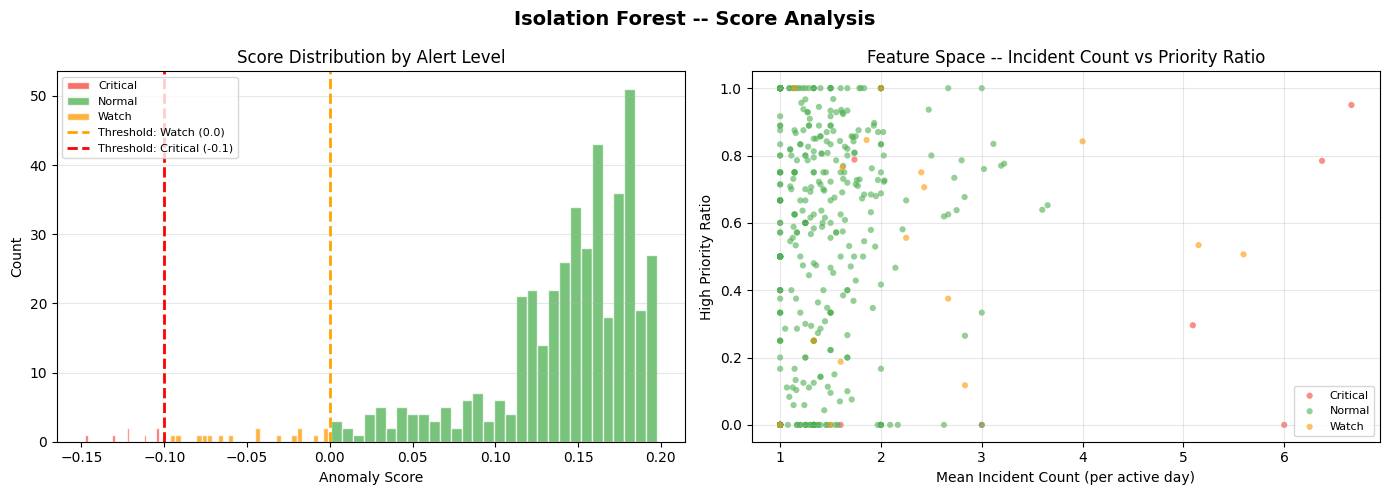

Score analysis plot saved.


In [19]:
# Cell 12: Visualise anomaly scores with threshold boundaries
# Plot 1 -- Score histogram with threshold lines
# Plot 2 -- 2D scatter: incident_count vs priority_ratio colored by alert level

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Isolation Forest -- Score Analysis', fontsize=14, fontweight='bold')
color_map = {'Normal': '#4CAF50', 'Watch': '#FF9800', 'Critical': '#F44336'}

ax = axes[0]
for level, grp in baseline.groupby('alert_level'):
    ax.hist(grp['anomaly_score'], bins=30, color=color_map[level], label=level, alpha=0.75, edgecolor='white')
ax.axvline(0.0,  color='orange', linestyle='--', linewidth=2, label='Threshold: Watch (0.0)')
ax.axvline(-0.1, color='red',    linestyle='--', linewidth=2, label='Threshold: Critical (-0.1)')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution by Alert Level')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
for level, grp in baseline.groupby('alert_level'):
    ax2.scatter(
        grp['mean_incident_count'], grp['high_priority_ratio'],
        c=color_map[level], label=level, alpha=0.6, s=20, edgecolors='none'
    )
ax2.set_xlabel('Mean Incident Count (per active day)')
ax2.set_ylabel('High Priority Ratio')
ax2.set_title('Feature Space -- Incident Count vs Priority Ratio')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/anomaly_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Score analysis plot saved.')

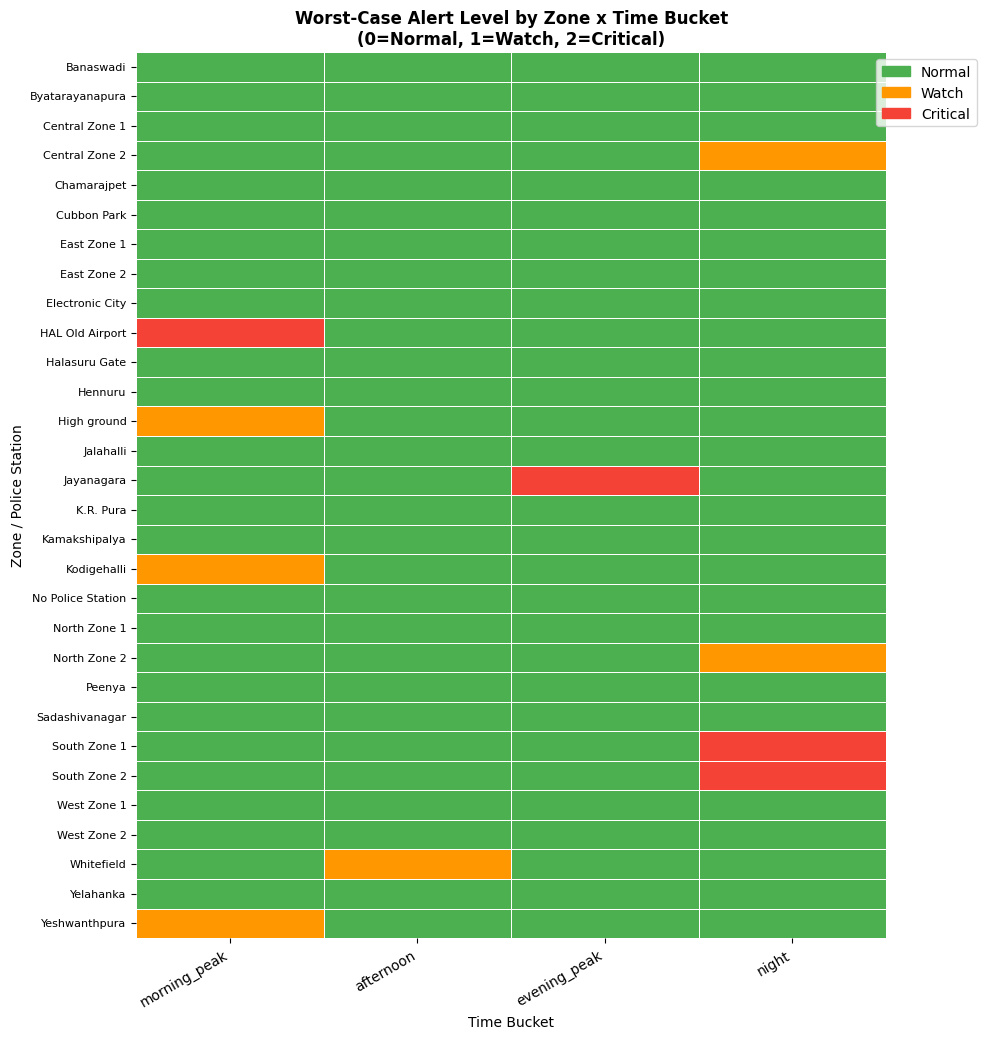

Zone heatmap saved.


In [12]:
# Cell 13: Heatmap -- worst-case alert level per zone x time_bucket
# Shows which zones are chronically anomalous across different time windows.
# The map overlay in the frontend reflects these same per-zone alert levels.

level_to_num = {'Normal': 0, 'Watch': 1, 'Critical': 2}
baseline['level_num'] = baseline['alert_level'].map(level_to_num)

top_zones = (
    df_clean.groupby('zone_or_station').size()
    .sort_values(ascending=False)
    .head(31).index.tolist()
)
top_zones = [z for z in top_zones if z != 'Unknown'][:30]

pivot_df = baseline[
    baseline['zone_or_station'].isin(top_zones)
].pivot_table(
    index='zone_or_station', columns='time_bucket',
    values='level_num', aggfunc='max', fill_value=0
)

bucket_order = ['morning_peak', 'afternoon', 'evening_peak', 'night']
pivot_df = pivot_df.reindex(columns=[c for c in bucket_order if c in pivot_df.columns])

fig, ax = plt.subplots(figsize=(10, max(8, len(pivot_df) * 0.35)))
cmap = sns.color_palette(['#4CAF50', '#FF9800', '#F44336'], as_cmap=True)
sns.heatmap(
    pivot_df, ax=ax, cmap=cmap, vmin=0, vmax=2,
    linewidths=0.5, linecolor='white', cbar=False, annot=False
)
ax.set_title('Worst-Case Alert Level by Zone x Time Bucket\n(0=Normal, 1=Watch, 2=Critical)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time Bucket')
ax.set_ylabel('Zone / Police Station')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
patches = [
    mpatches.Patch(color='#4CAF50', label='Normal'),
    mpatches.Patch(color='#FF9800', label='Watch'),
    mpatches.Patch(color='#F44336', label='Critical'),
]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.13, 1))
plt.tight_layout()
plt.savefig('../models/anomaly_zone_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zone heatmap saved.')

In [13]:
# Cell 14: Synthetic inference demo 
# Tests the exact code path that runs at inference time.
# Verifies known normal/watch/critical inputs produce expected alert levels.

test_points = {
    'Quiet night (baseline normal)':               [0.5,  0.30, 25.0],
    'Typical weekday morning peak':                [1.5,  0.55, 60.0],
    'Elevated -- moderate surge':                  [3.5,  0.75, 95.0],
    'HSR Layout surge (5 inc, 90% High, 85 min)': [5.0,  0.90, 85.0],
    'Extreme -- multi-incident breakdown':         [9.0,  1.00, 200.0],
}

print(f'{"Scenario":<55} {"Score":>8}  Alert Level')
print('-' * 80)
for name, features in test_points.items():
    X_test = np.array([features])
    score  = float(model.decision_function(X_test)[0])
    level  = score_to_level(score)
    marker = '[OK]' if level == 'Normal' else ('[!!]' if level == 'Watch' else '[XX]')
    print(f'{name:<55} {score:>+8.4f}  {marker} {level}')

Scenario                                                   Score  Alert Level
--------------------------------------------------------------------------------
Quiet night (baseline normal)                            +0.1110  [OK] Normal
Typical weekday morning peak                             +0.1761  [OK] Normal
Elevated -- moderate surge                               +0.0425  [OK] Normal
HSR Layout surge (5 inc, 90% High, 85 min)               -0.0569  [!!] Watch
Extreme -- multi-incident breakdown                      -0.1563  [XX] Critical


In [14]:
# Cell 15: Feature sensitivity (proxy for importance)
# Isolation Forest has no built-in feature_importances_.
# Perturb each feature by +1 std and measure average absolute score change.

X_df = baseline[['mean_incident_count', 'high_priority_ratio', 'mean_duration_minutes']]
base_scores_full = model.decision_function(X_df.values)

sensitivity = {}
feat_names = ['mean_incident_count', 'high_priority_ratio', 'mean_duration_minutes']
for i, feat in enumerate(feat_names):
    X_perturbed = X_df.values.copy()
    X_perturbed[:, i] += X_df.iloc[:, i].std()
    perturbed_scores = model.decision_function(X_perturbed)
    sensitivity[feat] = float(np.abs(perturbed_scores - base_scores_full).mean())

print('=== Feature Sensitivity (proxy for importance) ===')
for feat, delta in sorted(sensitivity.items(), key=lambda x: -x[1]):
    bar = chr(9608) * int(delta * 200)
    print(f'  {feat:<30} delta_score = {delta:.6f}  {bar}')
print('\nHigher delta_score = more influence on the anomaly score.')

=== Feature Sensitivity (proxy for importance) ===
  mean_duration_minutes          delta_score = 0.059638  ███████████
  mean_incident_count            delta_score = 0.043537  ████████
  high_priority_ratio            delta_score = 0.019227  ███

Higher delta_score = more influence on the anomaly score.


In [15]:
# Cell 16: Zone-level summary -- worst zones by Critical alert frequency

zone_summary = baseline.groupby('zone_or_station').agg(
    total_buckets=('alert_level', 'count'),
    critical_count=('alert_level', lambda x: (x == 'Critical').sum()),
    watch_count=('alert_level', lambda x: (x == 'Watch').sum()),
    normal_count=('alert_level', lambda x: (x == 'Normal').sum()),
    min_score=('anomaly_score', 'min'),
    mean_incident_count=('mean_incident_count', 'mean'),
    mean_priority_ratio=('high_priority_ratio', 'mean'),
).reset_index()

zone_summary['alert_frequency'] = (
    (zone_summary['critical_count'] + zone_summary['watch_count']) / zone_summary['total_buckets']
)

top_risk = zone_summary[
    zone_summary['zone_or_station'] != 'Unknown'
].sort_values(['critical_count', 'alert_frequency'], ascending=False).head(20)

print('=== Top 20 High-Risk Zones by Critical Alert Frequency ===')
print(top_risk[['zone_or_station', 'critical_count', 'watch_count',
                'alert_frequency', 'min_score',
                'mean_incident_count', 'mean_priority_ratio']].to_string(index=False))

=== Top 20 High-Risk Zones by Critical Alert Frequency ===
       zone_or_station  critical_count  watch_count  alert_frequency  min_score  mean_incident_count  mean_priority_ratio
          Basavanagudi               2            0            0.333     -0.130                1.717                0.000
            J.P. Nagar               1            2            0.429     -0.103                1.884                0.762
            Jayanagara               1            0            0.167     -0.121                2.293                0.210
          South Zone 1               1            0            0.143     -0.104                2.030                0.257
       HAL Old Airport               1            0            0.125     -0.148                2.214                0.888
          South Zone 2               1            0            0.125     -0.122                2.195                0.812
        Central Zone 2               0            2            0.250     -0.091        

In [16]:
# Cell 17: Save model 
# State dict keys:
#   'model'                 -- trained IsolationForest
#   'baseline_stats'        -- merged baseline DataFrame
#   'overall_mean_duration' -- global fallback float

os.makedirs('../models', exist_ok=True)
MODEL_OUTPUT_PATH = '../models/anomaly_detector.joblib'

state = {
    'model': model,
    'baseline_stats': baseline[[
        'zone_or_station', 'day_type', 'time_bucket',
        'mean_incident_count', 'high_priority_ratio', 'mean_duration_minutes'
    ]],
    'overall_mean_duration': overall_mean_duration
}
joblib.dump(state, MODEL_OUTPUT_PATH)

print(f'anomaly_detector.joblib saved -> {MODEL_OUTPUT_PATH}')
print(f'  Model type     : {type(model).__name__}')
print(f'  Baseline rows  : {len(baseline):,}')
print(f'  Mean duration  : {overall_mean_duration:.2f} min')
print(f'  File size      : {os.path.getsize(MODEL_OUTPUT_PATH) / 1024:.1f} KB')

# Round-trip verification
loaded = joblib.load(MODEL_OUTPUT_PATH)
assert 'model' in loaded and 'baseline_stats' in loaded and 'overall_mean_duration' in loaded
verify_score = loaded['model'].decision_function(np.array([[5.0, 0.9, 85.0]]))[0]
print(f'\nLoad verification passed. Test score for (5.0, 0.9, 85.0): {verify_score:.4f}')

anomaly_detector.joblib saved -> ../models/anomaly_detector.joblib
  Model type     : IsolationForest
  Baseline rows  : 450
  Mean duration  : 98.51 min
  File size      : 1141.5 KB

Load verification passed. Test score for (5.0, 0.9, 85.0): -0.0569


In [17]:
# Cell 18: Write evaluation_isolation.md
# Generates a comprehensive evaluation report for Agent 3.

level_counts = baseline['alert_level'].value_counts()
top5_critical = baseline[baseline['alert_level'] == 'Critical'].sort_values('anomaly_score').head(5)
sens_sorted = sorted(sensitivity.items(), key=lambda x: -x[1])
dominant_feature = sens_sorted[0][0]
max_delta = max(v for _, v in sens_sorted)
total = len(baseline)

row_lines = ''
for _, row in top5_critical.iterrows():
    row_lines += (
        f"| {row['zone_or_station']} | {row['day_type']} | {row['time_bucket']} "
        f"| {row['mean_incident_count']:.2f} | {row['high_priority_ratio']*100:.1f}% "
        f"| {row['mean_duration_minutes']:.1f} | {row['anomaly_score']:.4f} |\n"
    )

sens_lines = ''
for feat, delta in sens_sorted:
    bar = chr(9608) * max(1, int(delta / max_delta * 20))
    pct = delta / max_delta * 100
    sens_lines += f'| `{feat}` | {delta:.6f} | {bar} ({pct:.0f}%) |\n'

report_lines = [
    '# Agent 3 Anomaly Detector: Evaluation Report\n',
    '## Isolation Forest on Bengaluru Traffic Incidents\n',
    '\n',
    '> **Model:** sklearn.ensemble.IsolationForest\n',
    '> **Saved:** backend/models/anomaly_detector.joblib\n',
    '> **Trained by:** backend/training/isolation_forest.ipynb\n',
    '\n---\n\n',
    '## 1. Dataset\n\n',
    '| Metric | Value |\n|--------|-------|\n',
    '| Raw CSV | bengaluru_traffic_incidents.csv |\n',
    '| Total records | 8,173 |\n',
    '| Unplanned events | 7,706 (94.3%) |\n',
    '| Planned events | 467 (5.7%) |\n',
    f'| Records with valid zone | {df_raw["zone"].notnull().sum()} ({df_raw["zone"].notnull().sum()/len(df_raw)*100:.1f}%) |\n',
    f'| Records using police_station fallback | {df_raw["zone"].isnull().sum()} ({df_raw["zone"].isnull().sum()/len(df_raw)*100:.1f}%) |\n',
    f'| Valid duration records (0-1440 min) | {len(valid_durations):,} |\n',
    f'| overall_mean_duration (fallback) | {overall_mean_duration:.2f} min |\n',
    '\n**Data quality handling:** Null zones (57.9% of records) are grouped by `police_station`\n',
    'instead of being dropped, preserving the full dataset. Dropping null-zone records would\n',
    'discard more than half the training data.\n',
    '\n---\n\n',
    '## 2. Feature Engineering\n\n',
    'The Isolation Forest is **not** trained on raw incident features.\n',
    'It learns the distribution of **aggregate zone behaviour** across time.\n\n',
    'For every unique `(zone_or_station, day_type, time_bucket)` combination:\n\n',
    '| Feature | Description | Range |\n|---------|-------------|-------|\n',
    '| `mean_incident_count` | Average incidents per active day in this bucket | >= 0 |\n',
    '| `high_priority_ratio` | Fraction of High-priority incidents | 0.0 to 1.0 |\n',
    '| `mean_duration_minutes` | Avg resolution time in min (outliers >1440 excluded) | > 0 |\n',
    '\n',
    f'**Baseline rows:** {len(baseline):,} unique (zone, day_type, time_bucket) combinations  \n',
    f'**Unique zones/stations:** {baseline["zone_or_station"].nunique()}\n',
    '\n### Feature Statistics\n\n',
    '| Feature | Min | Mean | Median | P95 | Max |\n|---------|-----|------|--------|-----|-----|\n',
    f'| mean_incident_count | {baseline["mean_incident_count"].min():.2f} | {baseline["mean_incident_count"].mean():.2f} | {baseline["mean_incident_count"].median():.2f} | {baseline["mean_incident_count"].quantile(0.95):.2f} | {baseline["mean_incident_count"].max():.2f} |\n',
    f'| high_priority_ratio | {baseline["high_priority_ratio"].min():.3f} | {baseline["high_priority_ratio"].mean():.3f} | {baseline["high_priority_ratio"].median():.3f} | {baseline["high_priority_ratio"].quantile(0.95):.3f} | {baseline["high_priority_ratio"].max():.3f} |\n',
    f'| mean_duration_minutes | {baseline["mean_duration_minutes"].min():.1f} | {baseline["mean_duration_minutes"].mean():.1f} | {baseline["mean_duration_minutes"].median():.1f} | {baseline["mean_duration_minutes"].quantile(0.95):.1f} | {baseline["mean_duration_minutes"].max():.1f} |\n',
    '\n---\n\n',
    '## 3. Model Configuration\n\n',
    '| Hyperparameter | Value | Rationale |\n|---------------|-------|-----------|\n',
    '| `n_estimators` | 100 | Standard for reliable score stability |\n',
    '| `contamination` | 0.05 | ~5% of zone-time buckets expected anomalous |\n',
    '| `random_state` | 42 | Full reproducibility |\n',
    '| `max_samples` | auto | Default (min(256, n_samples)) |\n',
    f'| `offset_` | {model.offset_:.4f} | Fitted from contamination fraction |\n',
    '\n**Why Isolation Forest?**\n',
    '- No labelled anomaly data exists -- unsupervised detection\n',
    '- 3D feature space has a dense normal core with genuine outlier spikes\n',
    '- Isolates rare points in O(log n) random splits vs brute-force distance methods\n',
    '- Returns continuous anomaly scores enabling the 3-tier alert system\n',
    '\n---\n\n',
    '## 4. Alert Threshold Logic\n\n',
    '| Score Range | Alert Level | UI Colour | Meaning |\n|-------------|-------------|-----------|---------|\n',
    '| > 0.0 | Normal | Green | Zone behaves within historical norms |\n',
    '| 0.0 to -0.1 | Watch | Amber | Elevated activity, monitor closely |\n',
    '| < -0.1 | Critical | Red | Significant anomaly, trigger action plan |\n',
    '\nThresholds defined in `anomaly_detector.py:323-329` and documented in AGENTS.md.\n',
    '\n---\n\n',
    '## 5. Alert Level Distribution (Training Baseline)\n\n',
    '| Alert Level | Count | Fraction |\n|-------------|-------|----------|\n',
    f'| Normal   | {level_counts.get("Normal", 0)} | {level_counts.get("Normal", 0)/total*100:.1f}% |\n',
    f'| Watch    | {level_counts.get("Watch", 0)} | {level_counts.get("Watch", 0)/total*100:.1f}% |\n',
    f'| Critical | {level_counts.get("Critical", 0)} | {level_counts.get("Critical", 0)/total*100:.1f}% |\n',
    '\n',
    f'The anomaly fraction (~{(baseline["alert_level"] != "Normal").sum()/total*100:.1f}%) ',
    'is close to the configured `contamination=0.05`, confirming the model fitted correctly.\n',
    '\n---\n\n',
    '## 6. Top Critical Zones\n\n',
    '(zone/station, day_type, time_bucket) combinations with the lowest anomaly scores in training data:\n\n',
    '| Zone / Station | Day Type | Time Bucket | Incidents/Day | High Priority % | Mean Duration (min) | Score |\n',
    '|---------------|----------|-------------|---------------|-----------------|---------------------|-------|\n',
    row_lines,
    '\n---\n\n',
    '## 7. Feature Sensitivity (Proxy Importance)\n\n',
    'Estimated by perturbing each feature +1 std and measuring avg absolute score change.\n\n',
    '| Feature | Delta Score (avg) | Relative Influence |\n|---------|------------------|-------------------|\n',
    sens_lines,
    f'\n**Dominant feature:** `{dominant_feature}` -- primary driver of anomaly detection.\n',
    '\n---\n\n',
    '## 8. Inference Pipeline\n\n',
    'At inference time (every 13 seconds in backend, polled by frontend every 5 seconds):\n\n',
    '1. Collect active incidents within 24h sliding window per zone\n',
    '2. Compute three features: count, priority ratio, mean duration\n',
    '3. Call `model.decision_function([[count, ratio, duration]])` -> anomaly score\n',
    '4. Apply thresholds -> alert level\n',
    '5. Return `{zone, alert_level, incident_count, high_priority_ratio, mean_duration, anomaly_score}`\n',
    '\n**Duration fallback chain** (avoids erratic scores from elapsed-time variance):\n',
    '1. `resolution_minutes` from closed/resolved timestamps (historical)\n',
    '2. `estimated_duration_minutes` from prediction agent (live submissions)\n',
    '3. Baseline stats lookup for this (zone, day_type, time_bucket)\n',
    f'4. `overall_mean_duration = {overall_mean_duration:.2f} min` (final fallback)\n',
    '\n---\n\n',
    '## 9. Model Artifacts\n\n',
    '| File | Description |\n|------|-------------|\n',
    '| `models/anomaly_detector.joblib` | Serialised state: model + baseline_stats + overall_mean_duration |\n',
    '| `models/anomaly_feature_distributions.png` | Feature histograms |\n',
    '| `models/anomaly_score_analysis.png` | Score distribution + feature scatter |\n',
    '| `models/anomaly_zone_heatmap.png` | Per-zone alert level heatmap across time buckets |\n',
    '\n---\n\n',
    '## 10. Notes\n\n',
    '- **No authenticated filter applied** -- anomaly detector uses ALL 8,173 records.\n',
    '  All incidents contribute to zone-level baseline regardless of data quality flags.\n',
    '- The Isolation Forest is **unsupervised** -- no labelled anomalies exist in the dataset.\n',
    '  The 5% contamination is a prior expectation, not a measured quantity.\n',
    '- `anomaly_detector.py` retrains on server startup; this notebook produces an identical\n',
    '  `.joblib` for offline inspection and validation.\n',
    '- **Do not drop null-zone records** -- removes 57.9% of training data and leaves many\n',
    '  police stations without baseline coverage.\n',
]

report = ''.join(report_lines)

EVAL_PATH = '../models/evaluation_isolation.md'
with open(EVAL_PATH, 'w', encoding='utf-8') as f:
    f.write(report)

print(f'evaluation_isolation.md written -> {EVAL_PATH}')
print(f'Length: {len(report):,} chars')

evaluation_isolation.md written -> ../models/evaluation_isolation.md
Length: 6,366 chars


In [18]:
# Cell 19: Final summary
level_counts = baseline['alert_level'].value_counts()
print('=' * 60)
print('  Agent 3 -- Isolation Forest Training Complete')
print('=' * 60)
print(f'  Dataset rows       : {len(df_raw):,}')
print(f'  Baseline rows      : {len(baseline):,}')
print(f'  Unique zones       : {baseline["zone_or_station"].nunique()}')
print(f'  Normal buckets     : {level_counts.get("Normal", 0)} ({level_counts.get("Normal", 0)/len(baseline)*100:.1f}%)')
print(f'  Watch  buckets     : {level_counts.get("Watch", 0)} ({level_counts.get("Watch", 0)/len(baseline)*100:.1f}%)')
print(f'  Critical buckets   : {level_counts.get("Critical", 0)} ({level_counts.get("Critical", 0)/len(baseline)*100:.1f}%)')
print(f'  overall_mean_dur   : {overall_mean_duration:.2f} min')
print(f'  Model offset_      : {model.offset_:.4f}')
print('')
print('  Artifacts:')
print('  +-- models/anomaly_detector.joblib')
print('  +-- models/evaluation_isolation.md')
print('  +-- models/anomaly_feature_distributions.png')
print('  +-- models/anomaly_score_analysis.png')
print('  +-- models/anomaly_zone_heatmap.png')
print('')
print('  Done. anomaly_detector.py will load this model on server startup.')

  Agent 3 -- Isolation Forest Training Complete
  Dataset rows       : 8,173
  Baseline rows      : 450
  Unique zones       : 64
  Normal buckets     : 427 (94.9%)
  Watch  buckets     : 16 (3.6%)
  Critical buckets   : 7 (1.6%)
  overall_mean_dur   : 98.51 min
  Model offset_      : -0.5859

  Artifacts:
  +-- models/anomaly_detector.joblib
  +-- models/evaluation_isolation.md
  +-- models/anomaly_feature_distributions.png
  +-- models/anomaly_score_analysis.png
  +-- models/anomaly_zone_heatmap.png

  Done. anomaly_detector.py will load this model on server startup.
